In [19]:

!pip install wget

In [20]:
from wget import download
from os import path, listdir

if not path.exists("ObesityDataSet_raw_and_data_sinthetic.csv"):
    download("https://ignaciorlando.github.io/datasets/data-science/ObesityDataSet_raw_and_data_sinthetic.csv")
else:
    print("El archivo ya existe")
    

El archivo ya existe


In [21]:
lista_archivos = listdir("./")
print(f"El contenido de la carpeta es: {lista_archivos}")

El contenido de la carpeta es: ['.gitignore', 'reporte_streaming.html', 'reporte_netflix.html', 'tp3', 'tp3.ipynb', 'catalogo_streaming_argentina_2024.xlsx', 'ObesityDataSet_raw_and_data_sinthetic.csv', 'netflix_titles.csv', 'reporte_obesidad.html', '.ipynb_checkpoints']


In [22]:
import pandas as pd
leer_datos_obesidad = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
leer_datos_obesidad.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [23]:
leer_datos_obesidad["Age"] = leer_datos_obesidad["Age"].astype(int)
leer_datos_obesidad["NCP"] = leer_datos_obesidad["NCP"].astype(int)


In [24]:
leer_datos_obesidad.info()
leer_datos_obesidad.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   int64  
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   int64  
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21,Female,1.62,64.0,no,no,2.0,3,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21,Female,1.52,56.0,Sometimes,no,3.0,3,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23,Male,1.80,77.0,Frequently,no,2.0,3,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27,Male,1.80,87.0,Frequently,no,3.0,3,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22,Male,1.78,89.8,Sometimes,no,2.0,1,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# Ejercicio 1

In [25]:
import ydata_profiling as pr
report_datos_obesidad = pr.ProfileReport(leer_datos_obesidad)
report_datos_obesidad.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:00<00:00, 33459.96it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [26]:
report_datos_obesidad.to_file(output_file="reporte_obesidad.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
leer_datos_obesidad.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,23.972525,1.701677,86.586058,2.419043,2.523449,2.008011,1.010298,0.657866
std,6.308664,0.093305,26.191172,0.533927,0.830288,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.000000,1.630000,65.473343,2.000000,2.000000,1.584812,0.124505,0.000000
50%,22.000000,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


__Age__: Se puede observar que hay un sesgo hacia izquierda, se entrevisto a muchas personas alrededor de 18 a 21 años <br>
__Height__: Una altura bastante distribuida entre los valores entre 1.6 y 1.8 <br>
__weight__: Un peso basnate distribuida entre los valores, picos cerca de los 80, en 50 y luego 105 aprox. <br>
__FCVC__: Hay una clara eleccion en personas que consumen vegetales siempre y de vez en cuando. <br>
__NCP__: Se nota una eleccion hacia 3 comidas diarias. <br>
__CH20__: Hay una clara eleccion de consumicion de 2 l de agua diarios, mientras que 1 y 3 estan bastantes igual. <br>
__FAF__: la frecuencia esta sesgada al valor 0 de actividad fisica, mientras que sigue una lineal con pendiente negativa para los demas valores. <br>
__TUE__: la frecuencia esta sesgada al valor 0 de uso de disp. tecnologicos, mientras que sigue una lineal con pendiente negativa para los demas valores. <br>

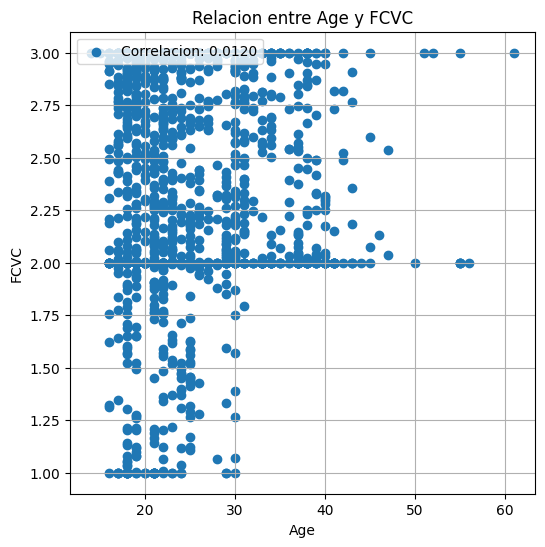

In [28]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

%matplotlib inline

# variable_1 = "Height"
# variable_2 = "Weight"
# variable_1 = "Age"
# variable_2 = "Weight"
variable_1 = "Age"
variable_2 = "FCVC"

datos_col_1 = leer_datos_obesidad[variable_1]
datos_col_2 = leer_datos_obesidad[variable_2]

plt.figure(figsize=(6,6))
plt.scatter(datos_col_1, datos_col_2)
plt.xlabel(variable_1)
plt.ylabel(variable_2)
plt.title("Relacion entre {} y {}" .format(variable_1, variable_2))

coeficiente_correlacion, _ = stats.pearsonr(datos_col_1, datos_col_2)
plt.legend([f"Correlacion: {coeficiente_correlacion:.4f}"], loc="upper left")

plt.grid(True)
plt.show()

__Primera hipotesis__: Eleji la altura y el peso, existe una relación positiva entre la altura y el peso, en general, a medida que aumenta Height, también tiende a aumentar Weight. Sin embargo, los puntos están bastante dispersos, por lo que la altura por sí sola no explica completamente el peso. <br>

__Segunda hipotesis__: Eleji el peso y la edad. Hay relación positiva débil entre la edad y el peso. El gráfico presenta una gran dispersión de los valores, por lo que la edad parece tener una relación limitada con el peso. <br>

__Tercera hipotesis__: Eleji la edad y el consumo de vegetales

# Ejercicio 2

In [29]:
if not path.exists("netflix_titles.csv"):
    download("https://ignaciorlando.github.io/datasets/data-science/netflix_titles.csv")
else: 
    print("El archivo ya existe")

lista_archivos_netflix = listdir("./")
print(f"El contenido del archivo es: {lista_archivos_netflix}")

El archivo ya existe
El contenido del archivo es: ['.gitignore', 'reporte_streaming.html', 'reporte_netflix.html', 'tp3', 'tp3.ipynb', 'catalogo_streaming_argentina_2024.xlsx', 'ObesityDataSet_raw_and_data_sinthetic.csv', 'netflix_titles.csv', 'reporte_obesidad.html', '.ipynb_checkpoints']


In [30]:
leer_datos_netflix = pd.read_csv("netflix_titles.csv", encoding="latin-1")
leer_datos_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
leer_datos_netflix = leer_datos_netflix.loc[:, ~leer_datos_netflix.columns.str.startswith("Unnamed")]
leer_datos_netflix.shape
leer_datos_netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8809 non-null   object
 1   type          8809 non-null   object
 2   title         8809 non-null   object
 3   director      6175 non-null   object
 4   cast          7984 non-null   object
 5   country       7978 non-null   object
 6   date_added    8799 non-null   object
 7   release_year  8809 non-null   int64 
 8   rating        8805 non-null   object
 9   duration      8806 non-null   object
 10  listed_in     8809 non-null   object
 11  description   8809 non-null   object
dtypes: int64(1), object(11)
memory usage: 826.0+ KB


In [32]:
leer_datos_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [33]:
report_datos_netflix = pr.ProfileReport(leer_datos_netflix)
#report_datos_netflix.to_notebook_iframe()
report_datos_netflix.to_file(output_file="reporte_netflix.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:02<00:00,  4.12it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [34]:
leer_datos_netflix.describe()

,release_year
count,8809.000000
mean,2014.181292
std,8.818932
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2024.000000


In [35]:
titulos_duplicados = leer_datos_netflix[leer_datos_netflix.duplicated(subset="title")]
print(titulos_duplicados)

     show_id     type   title            director  \
5964   s5965  TV Show  Feb-09                 NaN   
5965   s5966    Movie  22-Jul     Paul Greengrass   
5966   s5967    Movie  15-Aug  Swapnaneel Jayakar   

                                                   cast  \
5964  Shahd El Yaseen, Shaila Sabt, Hala, Hanadi Al-...   
5965  Anders Danielsen Lie, Jon Ãigarden, Jonas Str...   
5966  Rahul Pethe, Mrunmayee Deshpande, Adinath Koth...   

                             country        date_added  release_year rating  \
5964                             NaN    March 20, 2019          2018  TV-14   
5965  Norway, Iceland, United States  October 10, 2018          2018      R   
5966                           India    March 29, 2019          2019  TV-14   

      duration                             listed_in  \
5964  1 Season     International TV Shows, TV Dramas   
5965   144 min                     Dramas, Thrillers   
5966   124 min  Comedies, Dramas, Independent Movies   

        

__date_added__: Se puede observar un sesgo a derecha, la mayoria de los titulos se añadieron entre 2017 y 2020. <br>
__release_year__: Tambien se observa un sesgo a derecha, la mayoria de los titulos se lanzaron cerca del 2020. <br>

/tmp/ipykernel_3380/2275527849.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([datos_col_1_netflix[datos_col_2_netflix == tipo] for tipo in datos_col_2_netflix.unique()], labels=datos_col_2_netflix.unique())


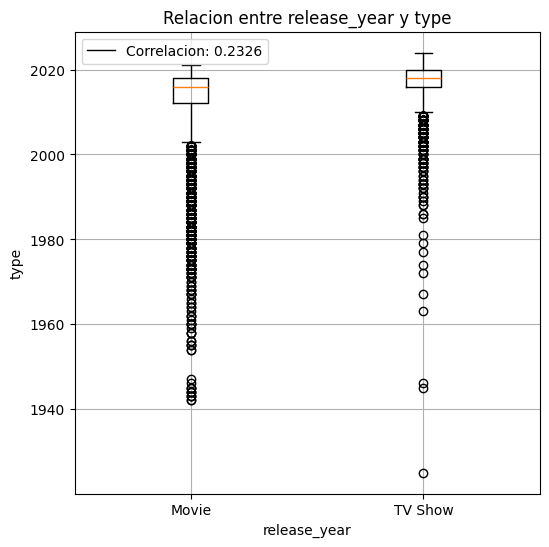

In [39]:
# variable_1_netflix = "rating"
# variable_2_netflix = "type"
# variable_1_netflix = "rating"
# variable_2_netflix = "release_year"
variable_1_netflix = "release_year"
variable_2_netflix = "type"

datos_col_1_netflix = leer_datos_netflix[variable_1_netflix]
datos_col_2_netflix = leer_datos_netflix[variable_2_netflix]

plt.figure(figsize=(6,6))
plt.boxplot([datos_col_1_netflix[datos_col_2_netflix == tipo] for tipo in datos_col_2_netflix.unique()], labels=datos_col_2_netflix.unique())
plt.xlabel(variable_1_netflix)
plt.ylabel(variable_2_netflix)
plt.title("Relacion entre {} y {}" .format(variable_1_netflix, variable_2_netflix))

coeficiente_correlacion, _ = stats.spearmanr(datos_col_1_netflix, datos_col_2_netflix)
plt.legend([f"Correlacion: {coeficiente_correlacion:.4f}"], loc="upper left")

plt.grid(True)
plt.show()

Preguntar que hacer si tengo solo una variable cuantitativa y calcular la correlacion

# Ejercicio 3

In [ ]:
if not path.exists("catalogo_streaming_argentina_2024.xlsx"):
    download("https://ignaciorlando.github.io/datasets/data-science/catalogo_streaming_argentina_2024.xlsx")
else:
    print("El archivo ya existe")

lista_archivos_streaming = listdir("./")
print(f"El contenido del archivo es: {lista_archivos_streaming}")

El archivo ya existe
El contenido del archivo es: ['.gitignore', 'reporte_netflix.html', 'tp3', 'tp3.ipynb', 'catalogo_streaming_argentina_2024.xlsx', 'ObesityDataSet_raw_and_data_sinthetic.csv', 'netflix_titles.csv', 'reporte_obesidad.html', '.ipynb_checkpoints']


In [ ]:
leer_datos_streaming = pd.read_excel("catalogo_streaming_argentina_2024.xlsx")
leer_datos_streaming.head()

,title,platform,type,imdbVotes,imdbScore,tmdbPopularity,tmdbScore,runtime,genres,director,year_range,url
0,Cadena perpetua,Max,MOVIE,2906253.0,9.3,159.594,8.705,142,"Drama, Crimen",Frank Darabont,1900_2002,https://play.max.com/movie/9b4dacba-2f80-4272-...
1,El caballero oscuro,Max,MOVIE,2893241.0,9.0,111.674,8.516,152,"Misterio & Suspense, Drama, Acción & Aventura,...",Christopher Nolan,2003_2010,https://play.max.com/movie/52217243-a137-45d6-...
2,Origen,Max,MOVIE,2570263.0,8.8,139.644,8.369,148,"Ciencia ficción, Acción & Aventura, Misterio &...",Christopher Nolan,2003_2010,https://play.max.com/movie/14552c93-d318-4563-...
3,El club de la lucha,Disney Plus,MOVIE,2345071.0,8.8,108.297,8.400,139,Drama,David Fincher,1998_2004,https://disneyplus.bn5x.net/c/1206980/705874/9...
4,El club de la lucha,Netflix,MOVIE,2345071.0,8.8,108.297,8.400,139,Drama,David Fincher,1995_2005,http://www.netflix.com/title/26004747


In [ ]:
report_datos_streaming = pr.ProfileReport(leer_datos_streaming)
report_datos_streaming.to_file(output_file="reporte_streaming")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:02<00:00,  5.31it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

/home/franco/Escritorio/Facultad/FundamentosCsDatos/TP3/tp3/lib/python3.12/site-packages/ydata_profiling/profile_report.py:386: UserWarning: Extension  not supported. For now we assume .html was intended. To remove this warning, please use .html or .json.
  warnings.warn(


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
leer_datos_streaming.describe()

,imdbVotes,imdbScore,tmdbPopularity,tmdbScore,runtime
count,1.785400e+04,17927.000000,19538.000000,18954.000000,19817.000000
mean,4.838858e+04,6.399520,41.195589,6.461363,80.542867
std,1.488473e+05,1.200258,131.031366,1.254487,37.092943
min,5.000000e+00,1.100000,0.001000,0.500000,0.000000
25%,4.620000e+02,5.700000,5.433250,5.889500,48.000000
50%,2.849500e+03,6.500000,14.428500,6.600000,89.000000
75%,2.196975e+04,7.300000,33.312500,7.273750,105.000000
max,2.906253e+06,9.700000,4173.518000,10.000000,263.000000


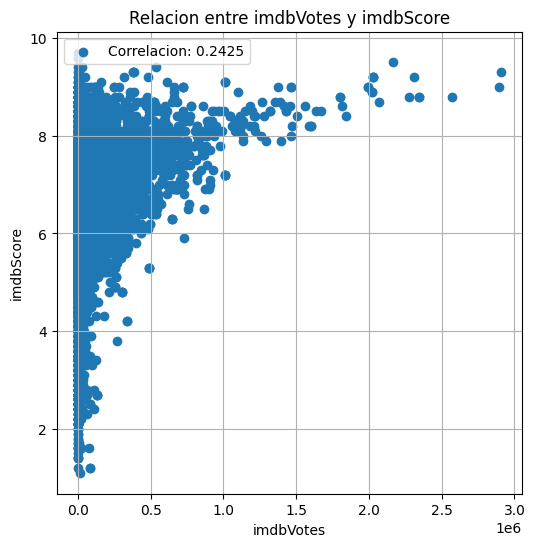

In [ ]:
variable_1_streaming = "imdbVotes"
variable_2_streaming = "imdbScore"
# variable_1_streaming = "tmdbPopularity"
# variable_2_streaming = "tmdbScore"
# variable_1_streaming = "tmdbPopularity"
# variable_2_streaming = "runtime"

#Elimino los NaN
datos_correlacion = leer_datos_streaming[[variable_1_streaming, variable_2_streaming]].dropna()

datos_col_1_streaming = datos_correlacion[variable_1_streaming]
datos_col_2_streaming = datos_correlacion[variable_2_streaming]

plt.figure(figsize=(6,6))
plt.scatter(datos_col_1_streaming, datos_col_2_streaming)
plt.xlabel(variable_1_streaming)
plt.ylabel(variable_2_streaming)
plt.title("Relacion entre {} y {}" .format(variable_1_streaming, variable_2_streaming))

coeficiente_correlacion, _ = stats.pearsonr(datos_col_1_streaming, datos_col_2_streaming)
plt.legend([f"Correlacion: {coeficiente_correlacion:.4f}"], loc="upper left")

plt.grid(True)
plt.show()

__Primera_Hipotesis__: 